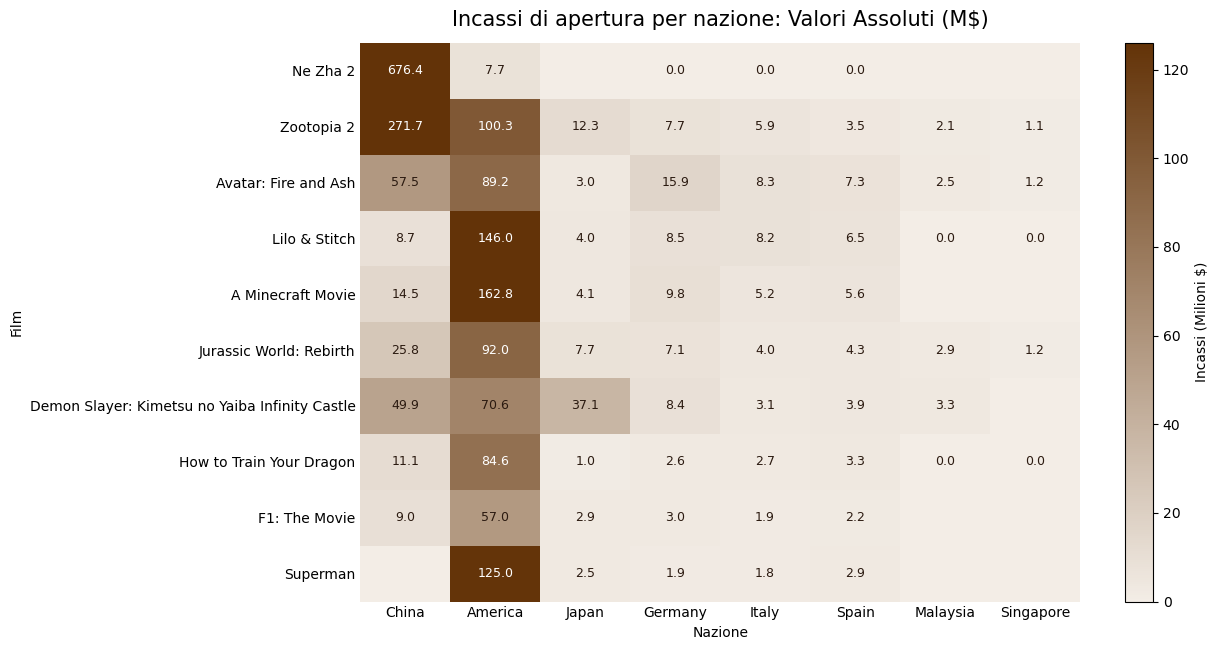

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import re

def parse_money_eu(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.lower() in ["", "-", "nan", "none"]:
        return np.nan
    s = re.sub(r"[€$]", "", s)
    s = s.replace(" ", "")
    s = re.sub(r"[^0-9,\.]", "", s)

    if s == "":
        return np.nan

    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    else:
        if s.count(".") >= 2 and "," not in s:
            s = s.replace(".", "")
        elif s.count(",") >= 2 and "." not in s:
            s = s.replace(",", "")
        else:
            if "," in s and "." not in s:
                s = s.replace(".", "").replace(",", ".")
            elif "." in s and "," not in s:
                parts = s.split(".")
                if len(parts[-1]) == 3 and all(len(p) <= 3 for p in parts[:-1]):
                    s = "".join(parts)

    try:
        return float(s)
    except:
        return np.nan

opening = pd.read_csv("opening.csv")
opening.columns = opening.columns.str.strip()

col_film = None
for c in opening.columns:
    if c.lower() in ["nome del film", "nome film", "movie", "film", "titolo", "title"]:
        col_film = c
        break
if col_film is None:
    col_film = opening.columns[0]

df = opening.copy()
df[col_film] = df[col_film].astype(str).str.strip()
df = df.set_index(col_film)

for c in df.columns:
    df[c] = df[c].apply(parse_money_eu)

df = df.dropna(how="all").fillna(0.0)

df_m = df / 1e6

tot_paese = df_m.sum(axis=0).sort_values(ascending=False)
df_m = df_m[tot_paese.index]

cmap = LinearSegmentedColormap.from_list("marrone_seq", ["#f3ede6", "#633308"])

fig1, ax1 = plt.subplots(figsize=(12.8, 6.6))

vmax = np.nanpercentile(df_m.values, 95)
im = ax1.imshow(df_m.values, aspect="auto", cmap=cmap, vmin=0, vmax=vmax)

ax1.set_title("Incassi di apertura per nazione: Valori Assoluti (M$)", fontsize=15, pad=12)
ax1.set_xlabel("Nazione")
ax1.set_ylabel("Film")

ax1.set_xticks(np.arange(len(df_m.columns)))
ax1.set_xticklabels(df_m.columns, rotation=0)
ax1.set_yticks(np.arange(len(df_m.index)))
ax1.set_yticklabels(df_m.index)

cbar = plt.colorbar(im, ax=ax1)
cbar.set_label("Incassi (Milioni $)")

for i in range(df_m.shape[0]):
    for j in range(df_m.shape[1]):
        val = df_m.iat[i, j]
        if val > 0:
            color_text = "white" if val > (vmax * 0.6) else "#2b1a10"
            ax1.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9, color=color_text)

for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.tick_params(length=0)

plt.tight_layout()
plt.show()